In [45]:
# coding: UTF-8
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import h5py
import csv
import math
import pandas as pd
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.animation as animation
from matplotlib.animation import ArtistAnimation

dir1 = '/Users/maedarn/Dropbox/code/code/zrad/data/'

xnH, T_K, T_gr_K, p = np.loadtxt(dir1+'1.dat', unpack=True)
xnH, y2, y23, y17, y33 = np.loadtxt(dir1+'2.dat', unpack=True)
xnH, xLmbd_C, xLmbd_OI, xLmbd_CII, xLmbd_CI  = np.loadtxt(dir1+'4.dat', unpack=True)
xnH, T_K = np.loadtxt(dir1+'nT.dat', unpack=True)

print( xLmbd_CII)

[6.85e-07 6.85e-07 6.85e-07 6.85e-07 6.85e-07 6.85e-07 6.85e-07 6.85e-07
 6.85e-07 6.85e-07 6.85e-07 6.85e-07 6.85e-07 6.85e-07 6.85e-07 6.87e-07
 7.02e-07 7.99e-07 9.66e-07 1.16e-06 1.40e-06 1.67e-06 1.99e-06 2.36e-06
 2.78e-06 3.26e-06 3.81e-06 4.41e-06 5.07e-06 5.77e-06 6.51e-06 7.22e-06
 7.87e-06 8.45e-06 8.95e-06 9.37e-06 9.70e-06 9.94e-06 1.01e-05 1.01e-05
 1.01e-05 9.91e-06 9.67e-06 9.33e-06 8.91e-06 8.42e-06 7.86e-06 7.24e-06
 6.57e-06 5.86e-06 5.14e-06 4.41e-06 3.70e-06 3.04e-06 2.43e-06 1.89e-06
 1.43e-06 1.05e-06 7.51e-07 5.22e-07 3.53e-07 2.34e-07 1.52e-07 9.83e-08
 6.42e-08 4.33e-08 3.10e-08 2.45e-08 2.07e-08 1.10e-08 1.38e-09 3.23e-11
 8.51e-13 3.88e-13 2.29e-13 1.51e-13 1.06e-13 7.77e-14 5.94e-14 4.75e-14
 3.98e-14 3.50e-14 3.18e-14 2.96e-14 2.80e-14 2.67e-14 2.57e-14 2.48e-14
 2.41e-14 2.35e-14 2.30e-14 2.25e-14 2.21e-14 2.17e-14 2.12e-14 2.07e-14
 2.00e-14 1.93e-14 1.85e-14 1.75e-14 1.64e-14 1.52e-14 1.39e-14 1.25e-14
 1.11e-14 9.79e-15 8.48e-15 7.25e-15 6.11e-15 5.07e

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


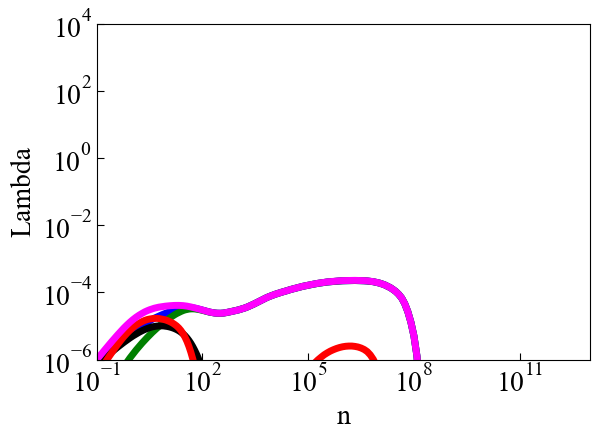

In [49]:
fig = plt.figure()
ax = fig.add_subplot(111)

plt.rcParams["font.family"] = "Times New Roman"      #全体のフォントを設定
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams['mathtext.default'] = 'it'
plt.rcParams["xtick.direction"] = "in"               #x軸の目盛線が内向き('in')か外向き('out')か双方向か('inout')
plt.rcParams["ytick.direction"] = "in"               #y軸の目盛線が内向き('in')か外向き('out')か双方向か('inout')
#plt.rcParams["xtick.minor.visible"] = True          #x軸補助目盛りの追加
#plt.rcParams["ytick.minor.visible"] = True          #y軸補助目盛りの追加
#plt.rcParams["xtick.major.width"] = 1.5              #x軸主目盛り線の線幅
#plt.rcParams["ytick.major.width"] = 1.5              #y軸主目盛り線の線幅
#plt.rcParams["xtick.minor.width"] = 1.0              #x軸補助目盛り線の線幅
#plt.rcParams["ytick.minor.width"] = 1.0              #y軸補助目盛り線の線幅
plt.rcParams["xtick.major.size"] = 5                #x軸主目盛り線の長さ
plt.rcParams["ytick.major.size"] = 5                #y軸主目盛り線の長さ
#plt.rcParams["xtick.minor.size"] = 5                #x軸補助目盛り線の長さ
#plt.rcParams["ytick.minor.size"] = 5                #y軸補助目盛り線の長さ
plt.rcParams["font.size"] = 20                       #フォントの大きさ
#plt.rcParams["axes.linewidth"] = 1.5                 #囲みの太さ
plt.xlim([0.1, 1.e13]) # x方向の描画範囲を指定
plt.ylim([1.e-6, 1.e4]) # y方向の描画範囲を指定
plt.rcParams["legend.markerscale"] = 2
plt.rcParams["legend.fancybox"] = False
plt.rcParams["legend.framealpha"] = 1
plt.rcParams["legend.edgecolor"] = 'black'

plt.xscale('log')
plt.yscale('log')
#plt.plot(xnH,T_K, color='red' , linestyle = "solid", markersize=2.5, linewidth = 5)
plt.plot(xnH,xLmbd_C, color='blue' , linestyle = "solid", markersize=2.5, linewidth = 5)
plt.plot(xnH,xLmbd_CI, color='green' , linestyle = "solid", markersize=2.5, linewidth = 5)
plt.plot(xnH,xLmbd_CII, color='black' , linestyle = "solid", markersize=2.5, linewidth = 5)
plt.plot(xnH,xLmbd_OI, color='red' , linestyle = "solid", markersize=2.5, linewidth = 5)
plt.plot(xnH,xLmbd_C+xLmbd_OI, color='magenta' , linestyle = "solid", markersize=2.5, linewidth = 5)
#plt.plot(xnH,y23, color='blue' , linestyle = "solid", markersize=2.5, linewidth = 5)
#plt.plot(xnH,y17, color='green' , linestyle = "solid", markersize=2.5, linewidth = 5)
#plt.plot(xnH,y33, color='red' , linestyle = "solid", markersize=2.5, linewidth = 5)

#グラフの軸
#plt.xlabel(data[data_col[0]].name)
#plt.ylabel(data[data_col[1]].name)
#plt.ylabel(data[data_col[7]].name)
#ax.set_title('Scatter plot')
ax.set_xlabel('n')
ax.set_ylabel('Lambda')

#plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0, fontsize=5,frameon=False)
plt.legend(bbox_to_anchor=(1, 1), loc='upper right', borderaxespad=0, fontsize=9,frameon=False)

#plt.xticks(np.arange(0, 60 + 1, 10))
#plt.yticks(np.arange(0, 20 + 1, 5))
#p = plt.plot([0.0, 60.0],[10.0, 10.0], "black", linestyle='dashed') # normal way
#p = plt.plot([0.0, 60.0],[7.6, 7.6], "red", linestyle='dashed') # normal way
#p = plt.plot([0.0, 60.0],[12.7, 12.7], "blue", linestyle='dashed') # normal way
fig.tight_layout()
#グラフ表示
plt.show()
#plt.figure(figsize=(5, 6))

# 保存するPDFファイル名
pp = PdfPages(dir1+'test.pdf')
# 画像をPDFとして保存する
pp.savefig(fig)
# PDFの保存終了
pp.close()
#plt.savefig("R-Vesc.png")